# Use Darts to train Arima and Exponential Smoothing models

## Load Data

In [4]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import ExponentialSmoothing, ARIMA
from darts.metrics import mape, rmse, mae, r2_score
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv("data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

In [8]:
df

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0


## Arima Model


In [10]:
ts = TimeSeries.from_dataframe(df, 'date', 'unit_sales')
ts

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [11]:
# Train test split
ts = TimeSeries.from_dataframe(df, 'date', 'unit_sales')
train, test = ts.split_before(pd.Timestamp('2014-01-01'))


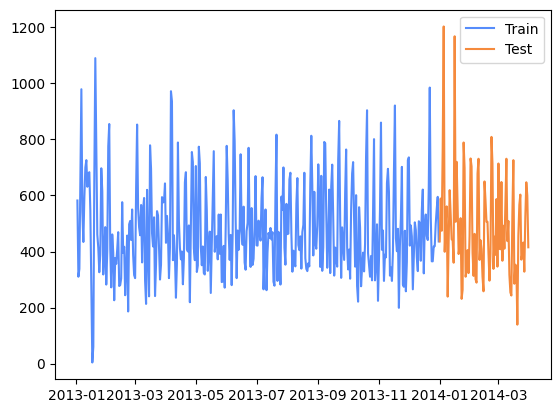

In [5]:
plt.plot(train.time_index, train.values(), label='Train')
plt.plot(test.time_index, test.values(), label='Test')
plt.legend()

In [45]:
# Train Arima model
arima_model = ARIMA(p=7, d=0, q=1)
arima_model.fit(train)

ARIMA(p=7, d=0, q=1, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [46]:
arima_model.predict(10)

,unit_sales
date,
2014-01-01,397.014560
2014-01-02,444.398426
2014-01-03,449.538522
2014-01-04,483.496948
2014-01-05,532.247661
2014-01-06,540.585502
2014-01-07,462.280751
2014-01-08,431.267383
2014-01-09,456.169141


In [47]:
# Forecast
arima_forecast = arima_model.predict(len(test))

In [48]:
test

,unit_sales
date,
2014-01-01,436.0
2014-01-02,589.0
2014-01-03,474.0
2014-01-04,767.0
2014-01-05,1203.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [49]:
# Evaluate Arima model
arima_mape = mape(test, arima_forecast)
arima_rmse = rmse(test, arima_forecast)
arima_mae = mae(test, arima_forecast)
arima_r2 = r2_score(test, arima_forecast)

print(f"ARIMA Model - MAPE: {arima_mape}, RMSE: {arima_rmse}, MAE: {arima_mae}, R2: {arima_r2}")

ARIMA Model - MAPE: 32.5635127751568, RMSE: 181.84464611257013, MAE: 140.45205992847949, R2: 0.017739428674807045


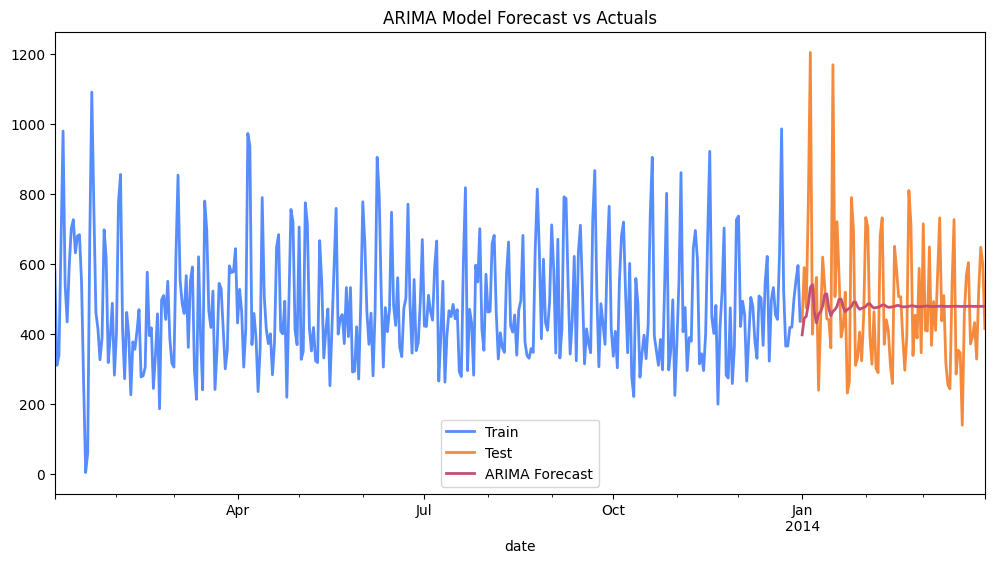

In [50]:
# Visualize Arima forecast against actuals

plt.figure(figsize=(12, 6))
train.plot(label='Train')
test.plot(label='Test')
arima_forecast.plot(label='ARIMA Forecast')
plt.title('ARIMA Model Forecast vs Actuals')
plt.legend()
plt.show()


## Exponential Smoothing Model

In [51]:

# Train Exponential Smoothing model
es_model = ExponentialSmoothing()
es_model.fit(train)
# Forecast
es_forecast = es_model.predict(len(test))

In [52]:

# Evaluate Exponential Smoothing model
es_mape = mape(test, es_forecast)
es_rmse = rmse(test, es_forecast)
es_mae = mae(test, es_forecast)
es_r2 = r2_score(test, es_forecast)
print(f"Exponential Smoothing Model - MAPE: {es_mape}, RMSE: {es_rmse}, MAE: {es_mae}, R2: {es_r2}")

Exponential Smoothing Model - MAPE: 20.896503072005675, RMSE: 142.95310635310042, MAE: 94.3735431589323, R2: 0.3929662086473864


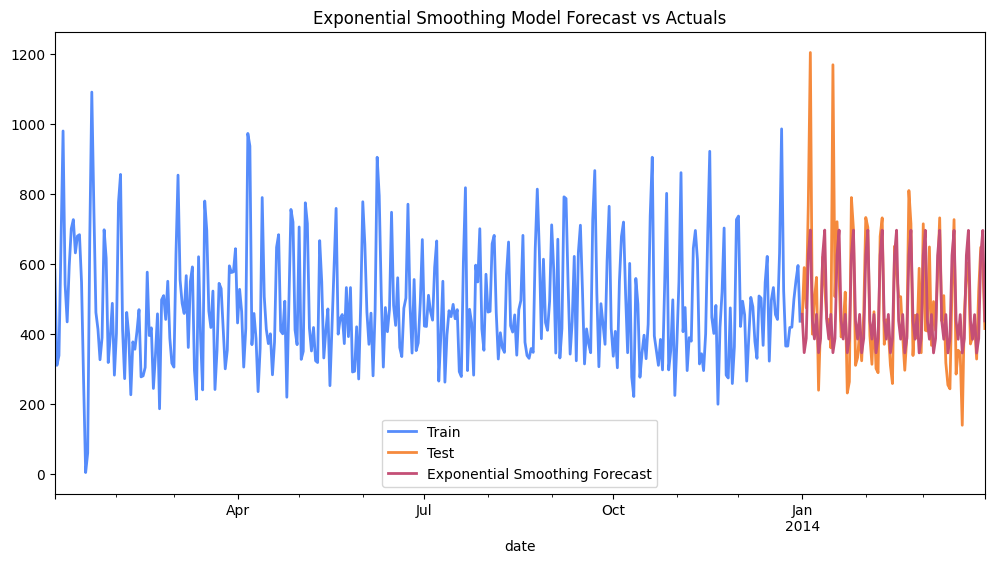

In [53]:

# Visualize Exponential Smoothing forecast against actuals
plt.figure(figsize=(12, 6))
train.plot(label='Train')
test.plot(label='Test')
es_forecast.plot(label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Model Forecast vs Actuals')
plt.legend()
plt.show()